## Download the data
#### Source: _Yahoo Finance_

In [2]:
from dataclasses import dataclass
from datetime import datetime
import pandas as pd
from typing import TypedDict
import yfinance as yf

@dataclass
class TickerHistory(TypedDict):
    name: str
    data: pd.DataFrame

def download_tickers_history(start_date: datetime, end_date: datetime, tickers: list[str]):   
    df_list = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        interval="1d",
        group_by="ticker",
        auto_adjust=True,
        threads=True,
        progress=True
    );

    return df_list;

# set the date range for the historic data
start_date = datetime(year=2020, month=1, day=1)
end_date = datetime(year=2025, month=12, day=31)
history = download_tickers_history(start_date, end_date, ['NVDA']);

history.NVDA

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,5.934969,5.963804,5.884506,5.963804,237536000
2020-01-03,5.844235,5.912099,5.819376,5.868348,205384000
2020-01-06,5.775129,5.898178,5.749027,5.892958,262636000
2020-01-07,5.921295,6.010040,5.876301,5.964300,314856000
2020-01-08,5.960073,6.016751,5.920051,5.975486,277108000
...,...,...,...,...,...
2025-12-23,182.747104,189.099356,182.677182,188.979507,174873600
2025-12-24,187.711052,188.679871,186.362690,188.380234,65528500
2025-12-26,189.688640,192.455270,187.770981,190.297897,139740300


## Basic data analytics

#### Returns
Working with raw prices (Close) is impossible in statistics, as they are non-stationary (the trend may be up or down, and the mathematical expectation may change over time). The first thing to do is to calculate the logarithmic return.

$$R_t = \ln(P_t / P_{t-1}) = \ln(P_t) - \ln(P_{t-1}),$$

where $t$ - time (day)

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anton\AppData\Local\Temp\ipykernel_25424\1837294060.py:33: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gauss distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'
C:\Users\Anton\AppData\Local\Temp\ipykernel_25424\1837294060.py:33: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gauss distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'


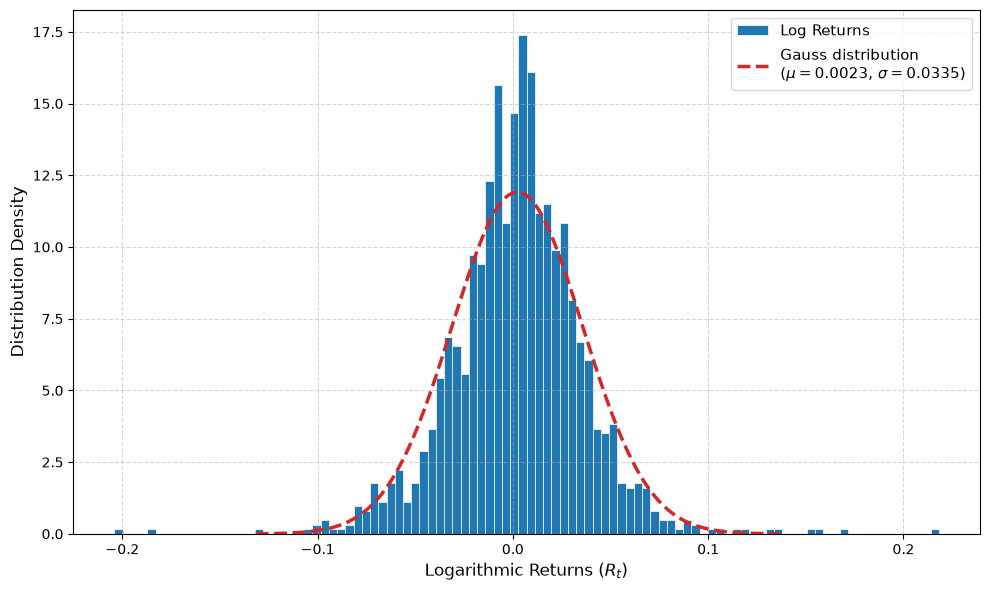

Skewness: 0.04475042984244752
Excess Kurtosis: 4.007301817055991


In [ ]:
import numpy as np;
import matplotlib.pyplot as plt;
from scipy.stats import norm

nvda = history.NVDA;
prices = nvda['Close'].to_numpy()
log_returns = np.diff(np.log(prices))

mu = np.mean(log_returns)
sigma = np.std(log_returns)

# data visualization
plt.figure(figsize=(10, 6))

plt.hist(
    log_returns, 
    density=True,
    bins=100,
    linewidth=0.5,
    edgecolor='w',
    label='Log Returns'
);

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
gauss = norm.pdf(x, loc=mu, scale=sigma)

plt.plot(
    x,
    gauss, 
    color='#d62728', 
    linewidth=2.5, 
    linestyle='--', 
    label=f'Gauss distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'
)

plt.xlabel('Logarithmic Returns ($R_t$)', fontsize=12)
plt.ylabel('Distribution Density', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show();


### Find the distribution

We're gonna use some quantitative criteria (Skewness and Excess Kurtosis), and also test test the hypothesis that the observed sample of returns follows a normal distribution using two different criterias:
* Pirson (Сhi-square)
* Shapiro-Wilk test

In [73]:
confidence_lvl = 0.95
alpha = 1 - confidence_lvl

In [41]:
from scipy.stats import skew, kurtosis

skewness = skew(log_returns)
excess_kurtosis = kurtosis(log_returns)

print("Skewness:", skewness)
print("Excess Kurtosis:", excess_kurtosis)

if skewness in [0.1, 0.5] or excess_kurtosis > 0:
    print("The distribution is likely NOT Normal.")
else:
    print("Looks like it is Normal distribution.")

Skewness: 0.04475042984244752
Excess Kurtosis: 4.007301817055991
The distribution is likely NOT Normal.


In [78]:
from scipy.stats import chisquare

# Normal with mu=0.0023 and sigma=0.0335
n = len(log_returns)

# split into intervals (bins)
num_bins = 20
observed_freq, bin_edges = np.histogram(log_returns, bins=num_bins)

# generate random 
cdf_values = norm.cdf(bin_edges, loc=mu, scale=sigma) # Gauss CDF
expected_prob = np.diff(cdf_values) # probability of falling into the i-th interval
expected_freq = expected_prob * n

expected_freq = expected_freq * (observed_freq.sum() / expected_freq.sum())

chi2_stat, p_value = chisquare(f_obs=observed_freq, f_exp=expected_freq, ddof=2)

print(f"Criterion statistics: {chi2_stat:.3f}")
print(f"P-value: {p_value:.5e}")

if p_value < alpha:
    print("Hypothesis H0 is rejected: The distribution IS NOT Normal.")
else:
    print("Hypothesis H0 IS NOT rejected: Looks like it is Normal distribution.")


Criterion statistics: 5018.481
P-value: 0.00000e+00
Hypothesis H0 is rejected: The distribution IS NOT Normal.


In [ ]:
from scipy.stats import shapiro

stat, p_value = shapiro(log_returns)
print(f"p-value: {p_value}")

if p_value < alpha:
    print("Hypothesis H0 is rejected: The distribution IS NOT Normal.")
else:
    print("Hypothesis H0 IS NOT rejected: Looks like it is Normal distribution.")



p-value: 1.1371558661284246e-18
Hypothesis H0 is rejected: The distribution IS NOT Normal.


### Prices log-normal distribution

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anton\AppData\Local\Temp\ipykernel_25424\4187342812.py:29: SyntaxWarning: invalid escape sequence '\m'
  label=f'Log-normal distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'
C:\Users\Anton\AppData\Local\Temp\ipykernel_25424\4187342812.py:29: SyntaxWarning: invalid escape sequence '\s'
  label=f'Log-normal distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'


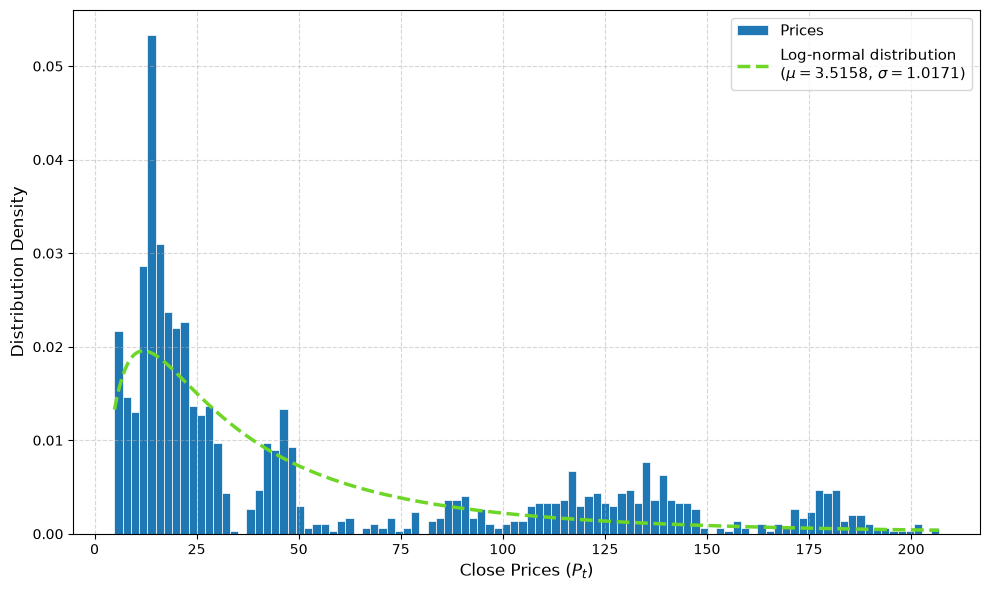

In [69]:
from scipy.stats import lognorm

log_prices = np.log(prices)
mu = np.mean(log_prices)
sigma = np.std(log_prices)
scale = np.exp(mu)

# data visualization
plt.figure(figsize=(10, 6))

plt.hist(
    prices, 
    density=True,
    bins=100,
    linewidth=0.5,
    edgecolor='w',
    label='Prices'
);

x = np.linspace(np.min(prices), np.max(prices), 500)
log_norm = lognorm.pdf(x, s=sigma, scale=scale)

plt.plot(
    x,
    log_norm, 
    color="#6dd627", 
    linewidth=2.5, 
    linestyle='--', 
    label=f'Log-normal distribution\n($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)'
)

plt.xlabel('Close Prices ($P_t$)', fontsize=12)
plt.ylabel('Distribution Density', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show();


In [77]:
from scipy.stats import chisquare

# Log-normal with mu=0.3.5158 and sigma=1.0.171
n = len(prices)
log_prices = np.log(prices)
mu = np.mean(log_prices)
sigma = np.std(log_prices)
scale = np.exp(mu)

# split into intervals (bins)
num_bins = 20
observed_freq, bin_edges = np.histogram(prices, bins=num_bins)

cdf_values = lognorm.cdf(bin_edges, s=sigma, scale=scale) # log-normal CDF
expected_prob = np.diff(cdf_values) # probability of falling into the i-th interval
expected_freq = expected_prob * n

expected_freq = expected_freq * (observed_freq.sum() / expected_freq.sum())

chi2_stat, p_value = chisquare(f_obs=observed_freq, f_exp=expected_freq, ddof=2)

print(f"Criterion statistics: {chi2_stat:.3f}")
print(f"P-value: {p_value:.5e}")

if p_value < alpha:
    print("Hypothesis H0 is rejected: The distribution IS NOT Log-Normal.")
else:
    print("Hypothesis H0 IS NOT rejected: Looks like it is Log-Normal distribution.")

Criterion statistics: 835.693
P-value: 1.12152e-166
Hypothesis H0 is rejected: The distribution IS NOT Log-Normal.


## Volatility and volatility clustering
I'm going to think about volatility as the _std_ over the _returns_

Trying to build a Rolling Volatility over a window of, 20 trading days (roughly equivalent to a trading month)

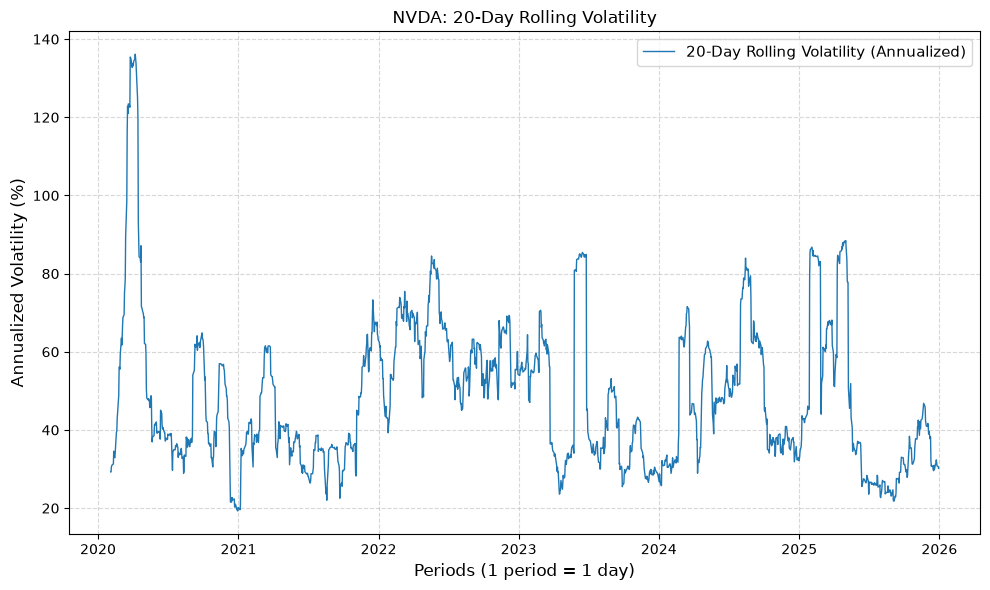

In [24]:
import numpy as np;
import matplotlib.pyplot as plt;

nvda = history.NVDA
prices = nvda['Close']
log_returns = np.diff(np.log(prices))

window = 20

rolling_vol_daily = np.array([np.std(log_returns[i:i+window]) for i in range(len(log_returns) - window)]) # len(log_returns) - window), since log_returns[i:i+window]

TRADING_DAYS_PER_YEAR = 252
rolling_vol_annual = rolling_vol_daily * np.sqrt(TRADING_DAYS_PER_YEAR) * 100 # (%)

dates = prices.index[window + 1:]

# data visualization
plt.figure(figsize=(10, 6))

plt.plot(
    dates,
    rolling_vol_annual,
    linewidth=1,
    label='20-Day Rolling Volatility (Annualized)'
);

plt.title('NVDA: 20-Day Rolling Volatility')
plt.xlabel('Periods (1 period = 1 day)', fontsize=12)
plt.ylabel('Annualized Volatility (%)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

## Volatility x Volume

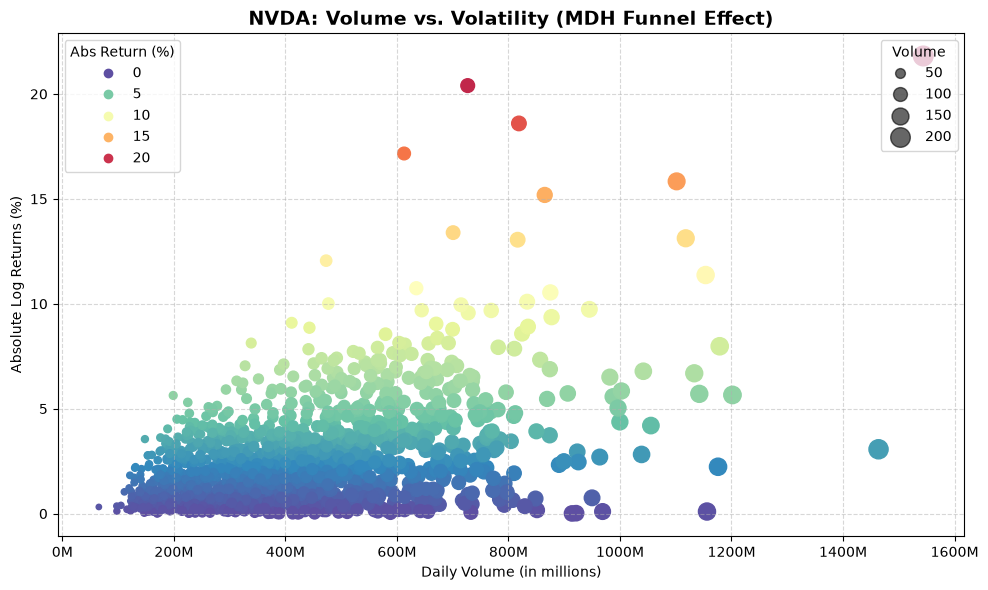

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

nvda = history.NVDA

log_returns = np.diff(np.log(nvda.Close.values))
abs_log_returns_perc = np.abs(log_returns) * 100 # (%)

volume = nvda.Volume.values[1:]

v_min, v_max = np.min(volume), np.max(volume)
size = 15 + (volume - v_min) / (v_max - v_min) * 185

# data visualization
fig, ax = plt.subplots(figsize=(10, 6));

scatter = ax.scatter(volume, abs_log_returns_perc, c=abs_log_returns_perc, s=size, cmap="Spectral_r")

# disable scientific notation & offset on X-axis to show full numbers
ax.ticklabel_format(style='plain', useOffset=False, axis='x')

ax.set_title("NVDA: Volume vs. Volatility (MDH Funnel Effect)", fontsize=14, fontweight='bold')
ax.set_xlabel("Daily Volume (in millions)")
ax.set_ylabel("Absolute Log Returns (%)")

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
legend1 = ax.legend(*scatter.legend_elements(num=5),
                    loc="upper left", title="Abs Return (%)")
ax.add_artist(legend1)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=5)
legend2 = ax.legend(handles, labels, loc="upper right", title="Volume")

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()
